# Proyek Analisis Data: [Brazilian E-Commerce Public Dataset by Olist]
- **Nama:** [Nanda Dwi Arinda]
- **Email:** [arindanandadwi@gmail.com]
- **ID Dicoding:** [nanda_dwi_arinda_q8]

## Menentukan Pertanyaan Bisnis

- Bagaimana tren jumlah order pada periode 2017–2018 dan pada bulan apa penjualan mencapai puncaknya?
- Kota mana saja yang termasuk dalam 10 besar dengan jumlah customer terbanyak pada periode 2017–2018, dan bagaimana kontribusinya terhadap total customer sehingga dapat dijadikan dasar penentuan strategi pemasaran yang lebih terarah?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv


## Data Wrangling

### Gathering Data

In [3]:
customers = pd.read_csv('olist_customers_dataset.csv')
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
orders = pd.read_csv('olist_orders_dataset.csv')
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Data customer menunjukkan bahwa sebagian besar pelanggan berasal dari kota dan state tertentu (misalnya banyak dari SP), yang mengindikasikan bahwa aktivitas transaksi cenderung terpusat di wilayah tersebut.
- Pada data orders terlihat bahwa mayoritas status pesanan adalah delivered, yang menunjukkan bahwa proses pemesanan hingga pengiriman berjalan dengan baik dan tingkat keberhasilan transaksi cukup tinggi.

### Assessing Data

In [5]:
display(customers.info())
display(orders.info())

display(customers.isnull().sum())
display(orders.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


None

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


**Insight:**
- Data pada kedua dataset memiliki jumlah baris yang sama dan tidak terdapat missing value pada kolom utama seperti customer_id dan order_id, sehingga data siap untuk digabungkan.
- Terdapat beberapa missing value pada kolom terkait pengiriman, yang kemungkinan disebabkan oleh proses order yang belum selesai atau status tertentu dalam transaksi.

### Cleaning Data

In [6]:
orders = orders.drop(columns=[
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
])

In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_estimated_delivery_date  99441 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


**Insight:**
- Beberapa kolom yang tidak digunakan dalam analisis telah dihapus sehingga dataset menjadi lebih sederhana dan lebih fokus pada informasi utama seperti status order dan waktu pembelian.
- Seluruh data pada kolom yang tersisa tidak memiliki missing value, sehingga data sudah bersih dan siap digunakan untuk analisis lebih lanjut tanpa perlu penanganan tambahan.

### Merge Data

In [8]:
customers = pd.read_csv('olist_customers_dataset.csv')

# merge dengan orders yang sudah kamu cleaning
df = pd.merge(orders, customers, on='customer_id')

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [9]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_estimated_delivery_date  99441 non-null  object
 5   customer_unique_id             99441 non-null  object
 6   customer_zip_code_prefix       99441 non-null  int64 
 7   customer_city                  99441 non-null  object
 8   customer_state                 99441 non-null  object
dtypes: int64(1), object(8)
memory usage: 6.8+ MB


(99441, 9)

In [10]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 5   customer_unique_id             99441 non-null  object        
 6   customer_zip_code_prefix       99441 non-null  int64         
 7   customer_city                  99441 non-null  object        
 8   customer_state                 99441 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(6)
memory usage: 6.8+ MB


In [12]:
df.to_csv("main_data.csv", index=False)

In [13]:
from google.colab import files

files.download("main_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Exploratory Data Analysis (EDA)

### Explore Statistik Deskriptif & Distribusi Data


In [14]:
# membuat kolom bulan dari tanggal pembelian
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

# menghitung jumlah order per bulan
monthly_orders = df.groupby('month')['order_id'].nunique()

monthly_orders.head()

,order_id
month,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780


**Insight:**
- Data menunjukkan bahwa jumlah order dapat dianalisis berdasarkan waktu dengan menggunakan kolom timestamp.
- Terlihat adanya variasi jumlah transaksi pada setiap bulan yang menunjukkan pola tertentu dalam aktivitas pembelian.

### EDA Univariate: Distributif Tiap Variabel

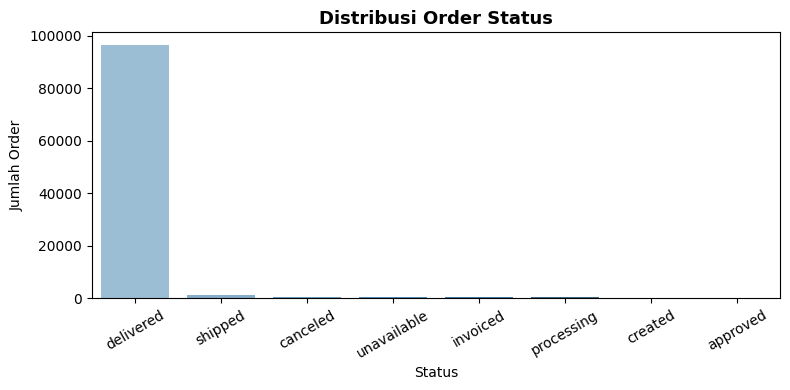

In [15]:
# 1. Distribusi Order Status
plt.figure(figsize=(8, 4))
order_status_counts = df["order_status"].value_counts()
sns.barplot(
    x=order_status_counts.index,
    y=order_status_counts.values,
    hue=order_status_counts.index,
    palette="Blues_d",
    legend=False
)
plt.title("Distribusi Order Status", fontsize=13, fontweight="bold")
plt.xlabel("Status")
plt.ylabel("Jumlah Order")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Insight**
- Mayoritas order berstatus delivered ini menunjukkan bahwa sebagian besar transaksi berhasil diselesaikan dan sistem pengiriman berjalan dengan baik.
- Masih ada order yang canceled dan unavailable walaupun jumlahnya kecil, ini menandakan adanya potensi masalah seperti stok tidak tersedia atau pembatalan dari pelanggan yang perlu dievaluasi.

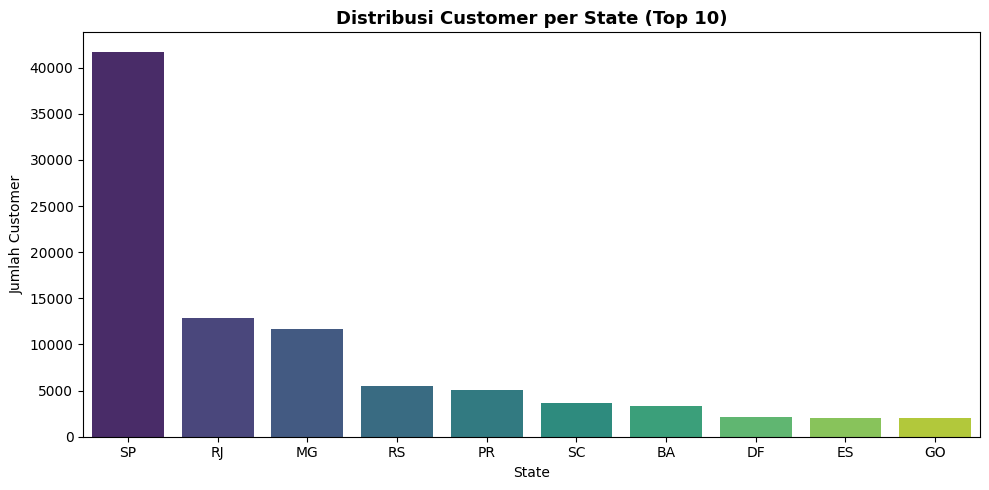

In [16]:
plt.figure(figsize=(10, 5))
top_state = df["customer_state"].value_counts().head(10)

sns.barplot(
    x=top_state.index,
    y=top_state.values,
    hue=top_state.index,
    palette="viridis",
    legend=False
)

plt.title("Distribusi Customer per State (Top 10)", fontsize=13, fontweight="bold")
plt.xlabel("State")
plt.ylabel("Jumlah Customer")
plt.tight_layout()
plt.show()

**Insight**
- Jumlah ini berkali-kali lipat dibanding peringkat kedua (RJ ≈ 13.000), menunjukkan ketergantungan pasar yang sangat tinggi pada satu wilayah utama tersebut.

- Penurunan Drastis Menuju Peringkat Bawah
Setelah Top 3 (SP, RJ, MG), jumlah customer langsung merosot ke angka di bawah 6.000, menandakan adanya kesenjangan pasar yang lebar antara wilayah pusat bisnis dengan wilayah lainnya.

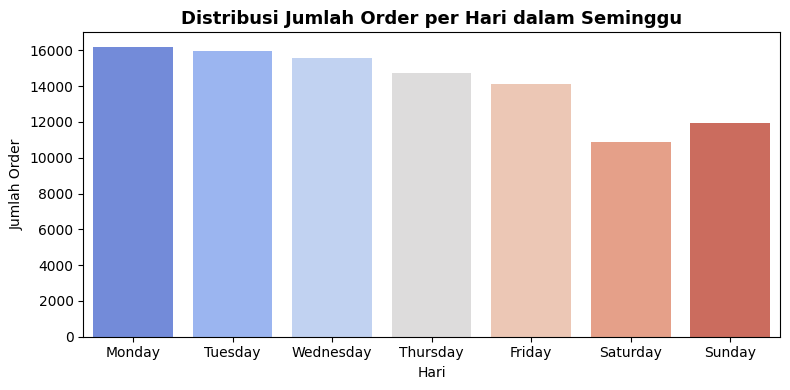

In [17]:
df["day_of_week"] = df["order_purchase_timestamp"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_counts = df["day_of_week"].value_counts().reindex(day_order).fillna(0)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=day_counts.index,
    y=day_counts.values,
    hue=day_counts.index,
    palette="coolwarm",
    legend=False
)

plt.title("Distribusi Jumlah Order per Hari dalam Seminggu", fontsize=13, fontweight="bold")
plt.xlabel("Hari")
plt.ylabel("Jumlah Order")
plt.tight_layout()
plt.show()

**Insight**
- Puncak Transaksi Terjadi di Hari Senin (±16.000 Order)
Hari Senin mencatat volume pesanan tertinggi dibandingkan hari lainnya. Terdapat tren penurunan jumlah order secara bertahap sejak awal pekan hingga mencapai titik terendah pada hari Sabtu.

- Penurunan Aktivitas Belanja di Akhir Pekan
Volume pesanan di hari Sabtu dan Minggu secara signifikan lebih rendah dibandingkan hari kerja (Senin-Jumat). Hal ini mengindikasikan bahwa perilaku belanja pelanggan lebih terkonsentrasi pada hari kerja dibandingkan saat masa libur akhir pekan.

### EDA Multivariate: Hubungan Antar Variabel

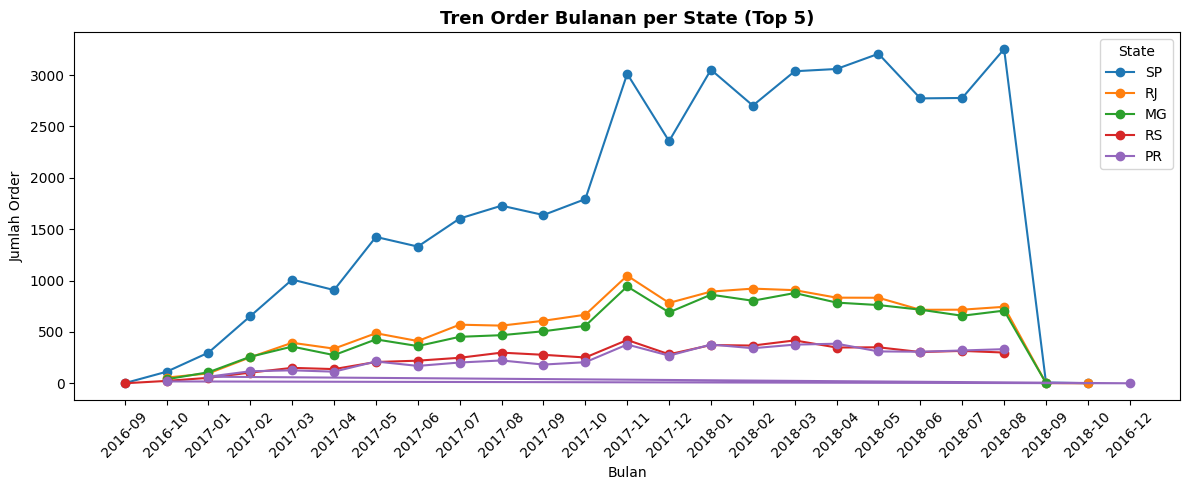

In [18]:
# 1. Tren Order per State (Top 5 State) dari waktu ke waktu
top5_states = df["customer_state"].value_counts().head(5).index.tolist()
df_top5 = df[df["customer_state"].isin(top5_states)].copy()
df_top5["month"] = df_top5["order_purchase_timestamp"].dt.to_period("M").astype(str)

monthly_state = df_top5.groupby(["month", "customer_state"])["order_id"].nunique().reset_index()
monthly_state.columns = ["month", "state", "order_count"]

plt.figure(figsize=(12, 5))
for state in top5_states:
    subset = monthly_state[monthly_state["state"] == state]
    plt.plot(subset["month"], subset["order_count"], marker="o", label=state)

plt.title("Tren Order Bulanan per State (Top 5)", fontsize=13, fontweight="bold")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Order")
plt.xticks(rotation=45)
plt.legend(title="State")
plt.tight_layout()
plt.show()


**Insight**
- State SP tidak hanya memiliki volume order tertinggi, tetapi juga menunjukkan tren pertumbuhan yang jauh lebih agresif dibandingkan state lainnya. Puncaknya terjadi pada sekitar Agustus 2018 dengan jumlah order melebihi 3.000
- Terdapat kenaikan tajam jumlah order di seluruh state pada bulan November 2017, dengan SP mencatat lonjakan paling drastis hingga menembus angka 3.000. Hal ini mengindikasikan adanya efek musiman yang sangat kuat atau keberhasilan kampanye promosi besar pada periode tersebut.

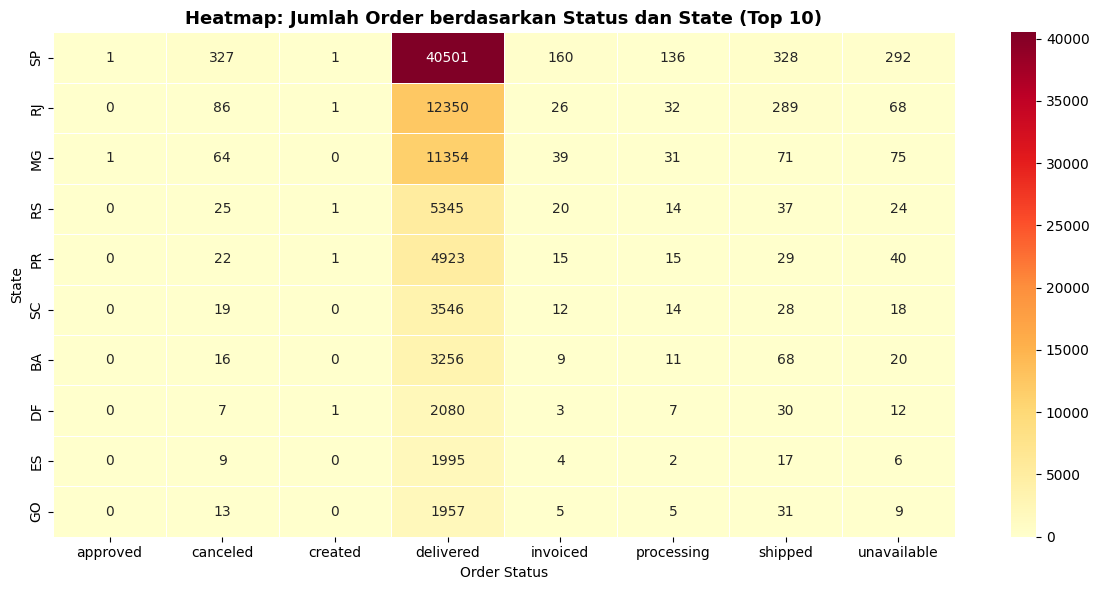

In [19]:
# 2. Order Status vs State (Heatmap)
status_state = df.groupby(["customer_state", "order_status"])["order_id"].nunique().unstack(fill_value=0)
top10_states = df["customer_state"].value_counts().head(10).index
status_state = status_state.loc[top10_states]

plt.figure(figsize=(12, 6))
sns.heatmap(
    status_state,
    annot=True, fmt="d", cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Heatmap: Jumlah Order berdasarkan Status dan State (Top 10)", fontsize=13, fontweight="bold")
plt.xlabel("Order Status")
plt.ylabel("State")
plt.tight_layout()
plt.show()


**Insight**
- Mayoritas pesanan di seluruh state berada pada status delivered. Hal ini menunjukkan bahwa sistem distribusi berjalan dengan baik, di mana sebagian besar transaksi berhasil diselesaikan hingga ke tangan pelanggan, terutama di SP dengan angka mencapai 40.501 order.
- Status canceled paling banyak ditemukan di state dengan volume transaksi tinggi, seperti SP (327) dan RJ (86). Meskipun secara persentase terlihat kecil dibanding total order, jumlah pembatalan di wilayah-wilayah ini perlu mendapat perhatian lebih untuk meminimalkan potensi kerugian operasional.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah order pada periode 2017–2018 dan pada bulan apa penjualan mencapai puncaknya?



In [20]:
# filter tahun 2017–2018
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

df_2017_2018 = df[df['year'].isin([2017, 2018])]

# hitung jumlah order per bulan
monthly_orders = df_2017_2018.groupby('month')['order_id'].nunique()


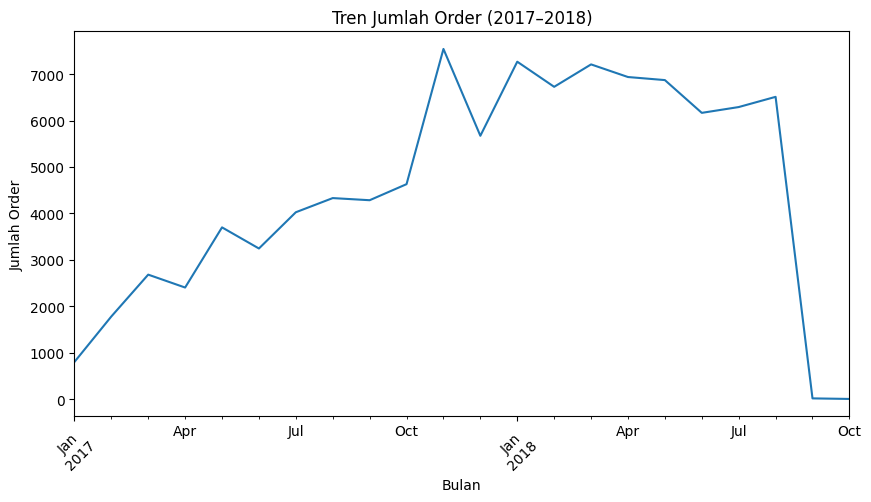

In [21]:
plt.figure(figsize=(10,5))
monthly_orders.plot()

plt.title('Tren Jumlah Order (2017–2018)')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')
plt.xticks(rotation=45)

plt.show()

In [22]:
peak_month = monthly_orders.idxmax()
peak_value = monthly_orders.max()

print("Bulan dengan penjualan tertinggi:", peak_month)
print("Jumlah order:", peak_value)

Bulan dengan penjualan tertinggi: 2017-11
Jumlah order: 7544


### Pertanyaan 2: Kota mana saja yang termasuk dalam 10 besar dengan jumlah customer terbanyak pada periode 2017–2018, dan bagaimana kontribusinya terhadap total customer sehingga dapat dijadikan dasar penentuan strategi pemasaran yang lebih terarah?

In [ ]:
top_city = df['customer_city'].value_counts().head(10)

top_city

,count
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
campinas,1444
porto alegre,1379
salvador,1245
guarulhos,1189


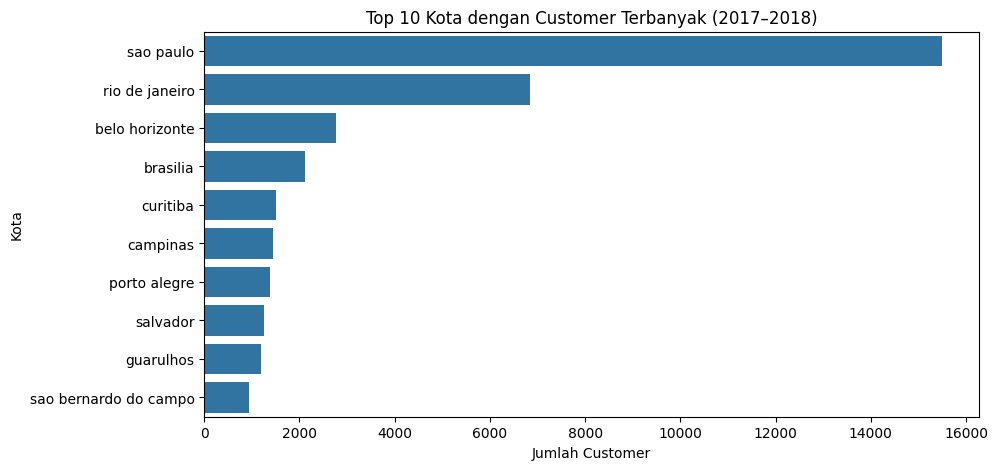

In [23]:
# filter periode 2017–2018
df['year'] = df['order_purchase_timestamp'].dt.year
df_filtered = df[df['year'].isin([2017, 2018])]

# top 10 kota
top_city = df_filtered['customer_city'].value_counts().head(10)

# ubah ke dataframe
top_city_df = top_city.reset_index()
top_city_df.columns = ['city', 'total_customer']

# hitung kontribusi (%)
top_city_df['percentage'] = (top_city_df['total_customer'] / top_city_df['total_customer'].sum()) * 100

# visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(data=top_city_df, x='total_customer', y='city')

plt.title('Top 10 Kota dengan Customer Terbanyak (2017–2018)')
plt.xlabel('Jumlah Customer')
plt.ylabel('Kota')

plt.show()

**Insight:**
- Customer sangat terkonsentrasi di kota besar, terutama São Paulo yang memiliki jumlah customer paling tinggi dibandingkan kota lainnya, menunjukkan dominasi pasar pada wilayah tersebut selama periode 2017–2018.
- Perbedaan jumlah customer yang cukup signifikan antara kota peringkat pertama dan kota lainnya menunjukkan adanya ketimpangan distribusi customer, sehingga strategi pemasaran dapat difokuskan pada kota besar sekaligus diperluas ke kota dengan potensi pertumbuhan.

### RFM


In [24]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

snapshot_date = df['order_purchase_timestamp'].max()

In [25]:
rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique'
})

In [26]:
rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique'
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency']

rfm.head()

,customer_id,recency,frequency
0,00012a2ce6f8dcda20d059ce98491703,337,1
1,000161a058600d5901f007fab4c27140,458,1
2,0001fd6190edaaf884bcaf3d49edf079,596,1
3,0002414f95344307404f0ace7a26f1d5,427,1
4,000379cdec625522490c315e70c7a9fb,198,1


## Analisis Lanjutan (Opsional)

In [27]:
order_per_customer = df.groupby('customer_unique_id')['order_id'].nunique()

order_per_customer.head()

,order_id
customer_unique_id,
0000366f3b9a7992bf8c76cfdf3221e2,1
0000b849f77a49e4a4ce2b2a4ca5be3f,1
0000f46a3911fa3c0805444483337064,1
0000f6ccb0745a6a4b88665a16c9f078,1
0004aac84e0df4da2b147fca70cf8255,1


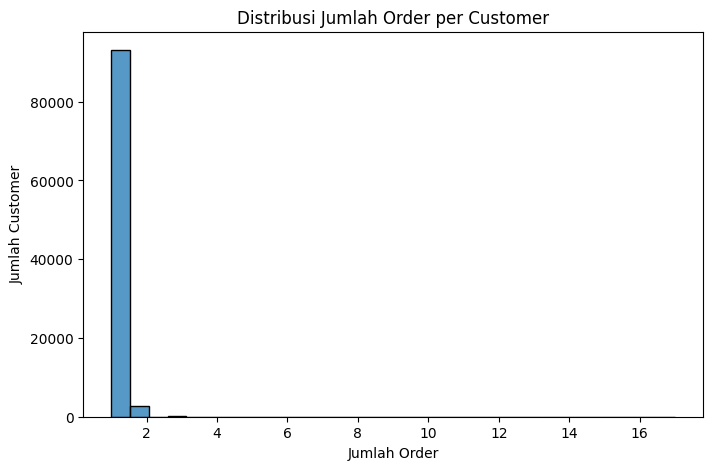

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(order_per_customer, bins=30)

plt.title('Distribusi Jumlah Order per Customer')
plt.xlabel('Jumlah Order')
plt.ylabel('Jumlah Customer')

plt.show()

**Insight**
- Sebagian besar customer hanya melakukan satu kali transaksi, yang menunjukkan rendahnya tingkat pembelian ulang.
- Hanya sebagian kecil customer yang melakukan pembelian berulang, sehingga diperlukan upaya untuk meningkatkan minat customer agar kembali bertransaksi.

## Conclusion

- Pertanyaan 1:

Pada periode 2017–2018, jumlah order menunjukkan tren peningkatan yang cukup signifikan dari waktu ke waktu, terutama sejak pertengahan 2017 hingga awal 2018, yang menandakan adanya pertumbuhan aktivitas transaksi pada platform e-commerce tersebut. Puncak penjualan terjadi pada bulan November 2017 dengan jumlah order sebesar 7.544, yang menjadi nilai tertinggi dibandingkan bulan lainnya.
Tren peningkatan yang disertai puncak penjualan pada periode tertentu menunjukkan adanya pola musiman dalam perilaku pembelian customer. Oleh karena itu, perusahaan dapat memanfaatkan periode dengan aktivitas tinggi tersebut untuk mengoptimalkan strategi pemasaran, seperti memberikan promo khusus, serta meningkatkan performa pada periode dengan transaksi lebih rendah.
- Pertanyaan 2:

Pada periode 2017–2018, São Paulo menjadi kota dengan jumlah customer tertinggi, jauh melampaui kota lainnya seperti Rio de Janeiro dan Belo Horizonte. Hal ini menunjukkan bahwa aktivitas transaksi sangat terpusat di kota besar dengan populasi dan aktivitas ekonomi yang tinggi.
Berdasarkan distribusi tersebut, strategi pemasaran sebaiknya difokuskan pada kota dengan jumlah customer tinggi untuk mempertahankan performa, serta memperluas jangkauan ke kota lain yang masih memiliki potensi pertumbuhan guna meningkatkan jumlah customer secara keseluruhan..